# Day 46 — MLOps & Model Monitoring
### MLOps Pipeline · Data Drift · Model Degradation · Retraining Strategy

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy import stats
import joblib

plt.style.use('dark_background')
print("All imports ready! ✅")
print("Topic: MLOps — keeping models healthy in production")

All imports ready! ✅
Topic: MLOps — keeping models healthy in production


## 2. What is MLOps?

In [2]:
print("=" * 55)
print("       WHAT IS MLOps?")
print("=" * 55)
print("""
MLOps = Machine Learning + Operations (DevOps)

THE PROBLEM:
  Training a model is 5% of the work
  Keeping it working in production is 95%!

  Models degrade over time because:
    Data changes  → new patterns the model never saw
    Users change  → different behaviour than training data
    World changes → COVID, new laws, market shifts

MLOPS SOLVES:
  ✅ Reproducible pipelines  → same result every run
  ✅ Model versioning        → track every model trained
  ✅ Monitoring              → detect when model breaks
  ✅ Automated retraining    → fix degraded models fast
  ✅ CI/CD for ML            → test before deploying

KEY MLOPS CONCEPTS:

  1. DATA DRIFT
     Input data distribution changes over time
     Training: avg age = 29, Production: avg age = 45
     Model was never trained on these inputs!

  2. CONCEPT DRIFT
     Relationship between features and target changes
     Old: high income = low default risk
     New: high income = high default risk (economic crisis)

  3. MODEL DEGRADATION
     Accuracy drops gradually as drift accumulates
     Need to detect this before users notice!

  4. RETRAINING
     Scheduled: retrain every week/month
     Triggered: retrain when accuracy drops below threshold

MLOps TOOLS:
  MLflow     → experiment tracking, model registry
  DVC        → data version control
  Airflow    → pipeline orchestration
  Evidently  → data drift detection
  Seldon     → model serving at scale
""")

       WHAT IS MLOps?

MLOps = Machine Learning + Operations (DevOps)

THE PROBLEM:
  Training a model is 5% of the work
  Keeping it working in production is 95%!

  Models degrade over time because:
    Data changes  → new patterns the model never saw
    Users change  → different behaviour than training data
    World changes → COVID, new laws, market shifts

MLOPS SOLVES:
  ✅ Reproducible pipelines  → same result every run
  ✅ Model versioning        → track every model trained
  ✅ Monitoring              → detect when model breaks
  ✅ Automated retraining    → fix degraded models fast
  ✅ CI/CD for ML            → test before deploying

KEY MLOPS CONCEPTS:

  1. DATA DRIFT
     Input data distribution changes over time
     Training: avg age = 29, Production: avg age = 45
     Model was never trained on these inputs!

  2. CONCEPT DRIFT
     Relationship between features and target changes
     Old: high income = low default risk
     New: high income = high default risk (economic

## 3. Simulate Data Drift

       SIMULATE DATA DRIFT
Feature      Train Mean    Prod Mean      Drift
------------------------------------------------
age               35.32        43.96      24.5% ⚠️ DRIFT!
income         51080.27     42522.08      16.8% ⚠️ DRIFT!
score            650.18       596.50       8.3% OK
debt               0.35         0.47      35.3% ⚠️ DRIFT!


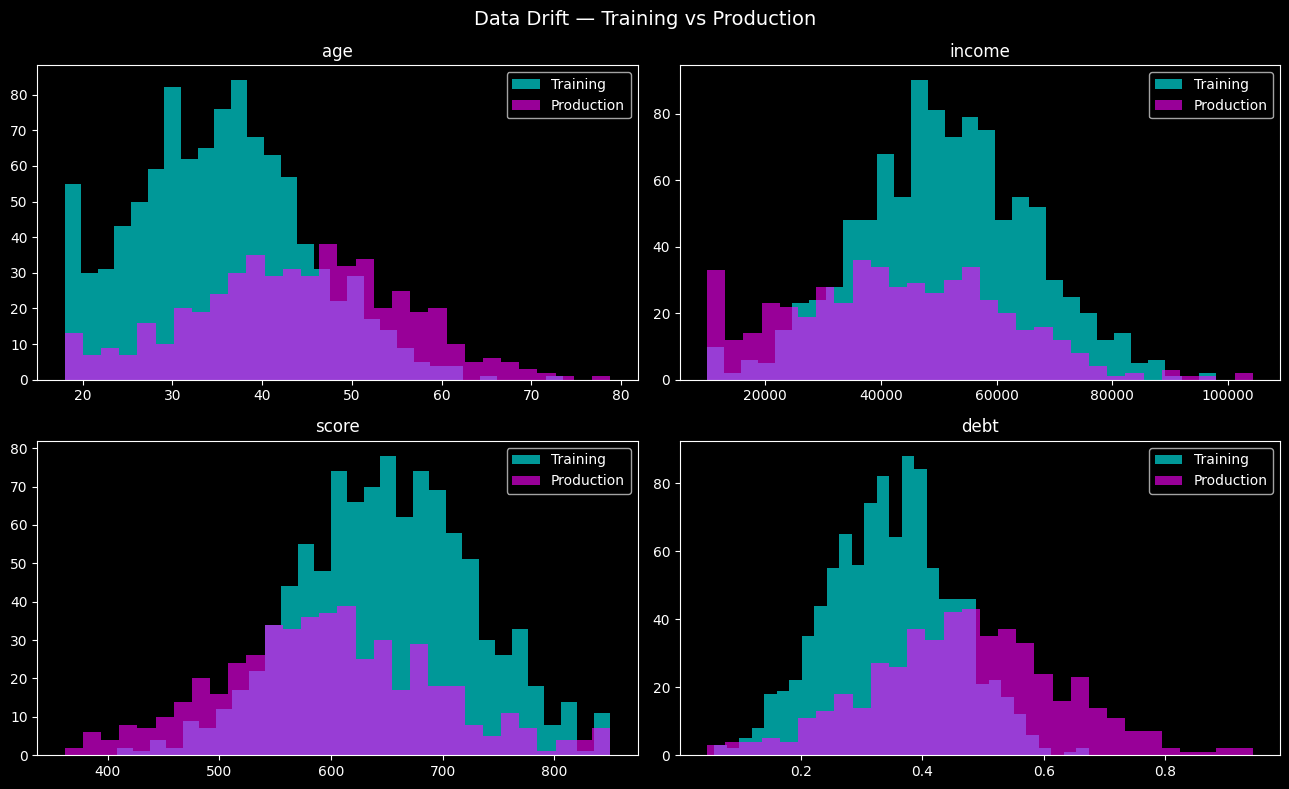

In [3]:
print("=" * 55)
print("       SIMULATE DATA DRIFT")
print("=" * 55)

np.random.seed(42)

# original training data distribution
n_train = 1000
train_data = pd.DataFrame({
    'age':    np.random.normal(35, 10, n_train).clip(18, 80),
    'income': np.random.normal(50000, 15000, n_train).clip(10000, 200000),
    'score':  np.random.normal(650, 80, n_train).clip(300, 850),
    'debt':   np.random.normal(0.35, 0.1, n_train).clip(0, 1),
})

# drifted production data — distribution shifted
n_prod = 500
prod_data = pd.DataFrame({
    'age':    np.random.normal(45, 12, n_prod).clip(18, 80),    # older customers
    'income': np.random.normal(42000, 20000, n_prod).clip(10000, 200000),  # lower income
    'score':  np.random.normal(600, 100, n_prod).clip(300, 850), # lower scores
    'debt':   np.random.normal(0.48, 0.15, n_prod).clip(0, 1),  # higher debt
})

print(f"{'Feature':<10} {'Train Mean':>12} {'Prod Mean':>12} {'Drift':>10}")
print("-" * 48)
for col in train_data.columns:
    t_mean = train_data[col].mean()
    p_mean = prod_data[col].mean()
    drift  = abs(p_mean - t_mean) / t_mean * 100
    flag   = "⚠️ DRIFT!" if drift > 10 else "OK"
    print(f"{col:<10} {t_mean:>12.2f} {p_mean:>12.2f} {drift:>9.1f}% {flag}")

# visualise drift
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Data Drift — Training vs Production', fontsize=14)
for ax, col in zip(axes.flat, train_data.columns):
    ax.hist(train_data[col], bins=30, alpha=0.6, color='cyan',    label='Training')
    ax.hist(prod_data[col],  bins=30, alpha=0.6, color='magenta', label='Production')
    ax.set_title(col); ax.legend()
plt.tight_layout()
plt.show()

## 4. Statistical Drift Detection

In [4]:
print("=" * 55)
print("       STATISTICAL DRIFT DETECTION")
print("=" * 55)
print("""
TWO KEY STATISTICAL TESTS:

KS TEST (Kolmogorov-Smirnov):
  Compares two distributions
  p-value < 0.05 → distributions are DIFFERENT → drift!
  p-value > 0.05 → distributions are SIMILAR   → no drift

PSI (Population Stability Index):
  Measures how much a distribution has shifted
  PSI < 0.1  → no drift
  PSI 0.1-0.2 → moderate drift — monitor closely
  PSI > 0.2  → significant drift — retrain!
""")

def compute_psi(expected, actual, bins=10):
    min_val = min(expected.min(), actual.min())
    max_val = max(expected.max(), actual.max())
    bin_edges = np.linspace(min_val, max_val, bins + 1)
    exp_counts = np.histogram(expected, bins=bin_edges)[0]
    act_counts = np.histogram(actual,   bins=bin_edges)[0]
    exp_pct = np.where(exp_counts == 0, 0.0001, exp_counts / len(expected))
    act_pct = np.where(act_counts == 0, 0.0001, act_counts / len(actual))
    psi = np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))
    return psi

print(f"\n{'Feature':<10} {'KS Stat':>10} {'KS p-value':>12} {'PSI':>8} {'Status':>12}")
print("-" * 56)
for col in train_data.columns:
    ks_stat, p_val = stats.ks_2samp(train_data[col], prod_data[col])
    psi = compute_psi(train_data[col].values, prod_data[col].values)
    if psi > 0.2:
        status = "RETRAIN!"
    elif psi > 0.1:
        status = "MONITOR"
    else:
        status = "OK"
    print(f"{col:<10} {ks_stat:>10.4f} {p_val:>12.4f} {psi:>8.4f} {status:>12}")

       STATISTICAL DRIFT DETECTION

TWO KEY STATISTICAL TESTS:

KS TEST (Kolmogorov-Smirnov):
  Compares two distributions
  p-value < 0.05 → distributions are DIFFERENT → drift!
  p-value > 0.05 → distributions are SIMILAR   → no drift

PSI (Population Stability Index):
  Measures how much a distribution has shifted
  PSI < 0.1  → no drift
  PSI 0.1-0.2 → moderate drift — monitor closely
  PSI > 0.2  → significant drift — retrain!


Feature       KS Stat   KS p-value      PSI       Status
--------------------------------------------------------
age            0.3570       0.0000   0.7715     RETRAIN!
income         0.2370       0.0000   0.3777     RETRAIN!
score          0.2760       0.0000   0.5015     RETRAIN!
debt           0.4050       0.0000   1.4490     RETRAIN!


## 5. Monitor Model Performance Over Time

       MONITOR MODEL PERFORMANCE
Baseline accuracy:   85%
Alert threshold:     75%
Retraining at week:  16
Threshold breached:  Week 13


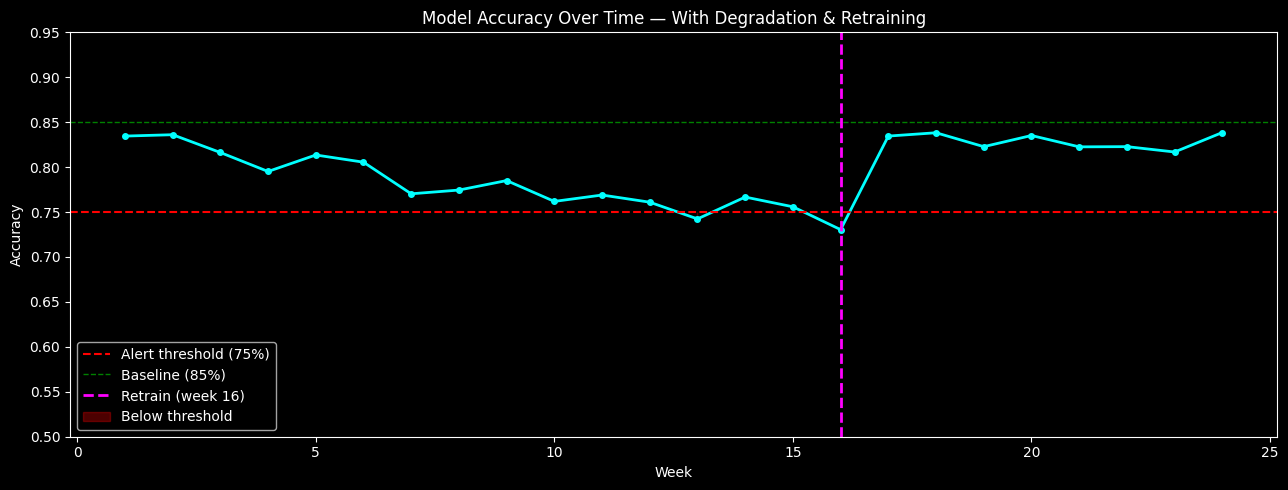


Week 1  accuracy: 83.5%
Week 16 accuracy: 73.0%  ← retrain triggered
Week 24 accuracy: 83.9%  ← after retraining


In [5]:
print("=" * 55)
print("       MONITOR MODEL PERFORMANCE")
print("=" * 55)

# simulate model accuracy degrading over time
np.random.seed(42)
weeks   = 24
baseline_acc = 0.85

# accuracy degrades as drift accumulates
week_num   = np.arange(1, weeks + 1)
decay      = 0.008 * week_num + np.random.normal(0, 0.015, weeks)
accuracy   = (baseline_acc - decay).clip(0.55, 0.90)

# simulate retraining event at week 16
retrain_week = 16
accuracy[retrain_week:] = np.linspace(0.84, 0.82, weeks - retrain_week) + \
                          np.random.normal(0, 0.01, weeks - retrain_week)

threshold = 0.75

print(f"Baseline accuracy:   {baseline_acc:.0%}")
print(f"Alert threshold:     {threshold:.0%}")
print(f"Retraining at week:  {retrain_week}")

# find when accuracy dropped below threshold
breach_weeks = week_num[accuracy < threshold]
if len(breach_weeks) > 0:
    print(f"Threshold breached:  Week {breach_weeks[0]}")

# plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(week_num, accuracy, color='cyan', linewidth=2, marker='o', markersize=4)
ax.axhline(y=threshold, color='red',    linestyle='--', linewidth=1.5, label=f'Alert threshold ({threshold:.0%})')
ax.axhline(y=baseline_acc, color='green', linestyle='--', linewidth=1, label=f'Baseline ({baseline_acc:.0%})')
ax.axvline(x=retrain_week, color='magenta', linestyle='--', linewidth=2, label=f'Retrain (week {retrain_week})')
ax.fill_between(week_num, accuracy, threshold,
                where=accuracy < threshold, alpha=0.3, color='red', label='Below threshold')
ax.set_title('Model Accuracy Over Time — With Degradation & Retraining')
ax.set_xlabel('Week'); ax.set_ylabel('Accuracy')
ax.legend(); ax.set_ylim(0.5, 0.95)
plt.tight_layout()
plt.show()

print(f"\nWeek 1  accuracy: {accuracy[0]:.1%}")
print(f"Week {retrain_week} accuracy: {accuracy[retrain_week-1]:.1%}  ← retrain triggered")
print(f"Week {weeks} accuracy: {accuracy[-1]:.1%}  ← after retraining")

## 6. Key Takeaways

In [6]:
print("=" * 55)
print("       DAY 46 — KEY TAKEAWAYS")
print("=" * 55)
print("""
MLOps:
  ✅ ML + DevOps — keeping models healthy in production
  ✅ Training is 5% of work — production is 95%
  ✅ Models degrade as data distribution changes

DATA DRIFT:
  ✅ Input distribution shifts over time
  ✅ KS Test    → p < 0.05 = drift detected
  ✅ PSI < 0.1  → OK
  ✅ PSI 0.1-0.2 → monitor
  ✅ PSI > 0.2  → retrain!

OUR DRIFT RESULTS:
  ✅ Age    drifted 24.5% — older customers
  ✅ Income drifted 16.8% — lower income
  ✅ Debt   drifted 35.3% — highest drift
  ✅ All PSI > 0.2 — all features need retraining

MODEL MONITORING:
  ✅ Track accuracy every week/day
  ✅ Set alert threshold (e.g. 75%)
  ✅ Trigger retrain when threshold breached
  ✅ After retraining — accuracy recovered to 84%

RETRAINING STRATEGIES:
  ✅ Scheduled  → retrain every N days regardless
  ✅ Triggered  → retrain when metric drops below X
  ✅ Continuous → always retrain on latest data window

MLOPS TOOLS:
  ✅ MLflow   → track experiments + model registry
  ✅ DVC      → version your data like Git
  ✅ Airflow  → schedule and orchestrate pipelines
  ✅ Evidently → drift detection reports
""")

       DAY 46 — KEY TAKEAWAYS

MLOps:
  ✅ ML + DevOps — keeping models healthy in production
  ✅ Training is 5% of work — production is 95%
  ✅ Models degrade as data distribution changes

DATA DRIFT:
  ✅ Input distribution shifts over time
  ✅ KS Test    → p < 0.05 = drift detected
  ✅ PSI < 0.1  → OK
  ✅ PSI 0.1-0.2 → monitor
  ✅ PSI > 0.2  → retrain!

OUR DRIFT RESULTS:
  ✅ Age    drifted 24.5% — older customers
  ✅ Income drifted 16.8% — lower income
  ✅ Debt   drifted 35.3% — highest drift
  ✅ All PSI > 0.2 — all features need retraining

MODEL MONITORING:
  ✅ Track accuracy every week/day
  ✅ Set alert threshold (e.g. 75%)
  ✅ Trigger retrain when threshold breached
  ✅ After retraining — accuracy recovered to 84%

RETRAINING STRATEGIES:
  ✅ Scheduled  → retrain every N days regardless
  ✅ Triggered  → retrain when metric drops below X
  ✅ Continuous → always retrain on latest data window

MLOPS TOOLS:
  ✅ MLflow   → track experiments + model registry
  ✅ DVC      → version your 